# Notebook 07 — Player Clustering

Cluster FIFA players into similar groups using the reusable `PlayerClusterer`.

## 1. Imports ##

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DATA_DIR

import duckdb
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

import joblib

## 2. Directories ##

In [2]:
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
TABLES_DIR.mkdir(parents=True, exist_ok=True)

## 3. Connection to DuckDB ##

In [3]:
con = duckdb.connect()

con.execute("PRAGMA threads=8")

PARQUET = PROCESSED_DATA_DIR / "players_clean"

## 4. Build Clustering Dataset ##

In [4]:
cluster_df = con.sql(f"""
SELECT

short_name,

TRY_CAST(age AS DOUBLE) AS age,
TRY_CAST(overall AS DOUBLE) AS overall,
TRY_CAST(potential AS DOUBLE) AS potential,
TRY_CAST(pace AS DOUBLE) AS pace,
TRY_CAST(shooting AS DOUBLE) AS shooting,
TRY_CAST(passing AS DOUBLE) AS passing,
TRY_CAST(dribbling AS DOUBLE) AS dribbling,
TRY_CAST(defending AS DOUBLE) AS defending,
TRY_CAST(physic AS DOUBLE) AS physic

FROM parquet_scan('{PARQUET}')

WHERE
    TRY_CAST(overall AS DOUBLE) IS NOT NULL
    AND TRY_CAST(age AS DOUBLE) IS NOT NULL

USING SAMPLE 200000 ROWS
""").df()

## 5. Clean Data ##

In [5]:
cluster_df = cluster_df.dropna()

cluster_df.shape

(177522, 10)

## 6. Feature Matrix ##

In [6]:
X = cluster_df.drop(columns=["short_name"])

## 7. Standardize ##

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## 8. Elbow Method ##

In [8]:
inertia = []

for k in range(2, 11):

    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10,
    )

    km.fit(X_scaled)

    inertia.append(km.inertia_)

## 9. Plot Elbow Curve ##

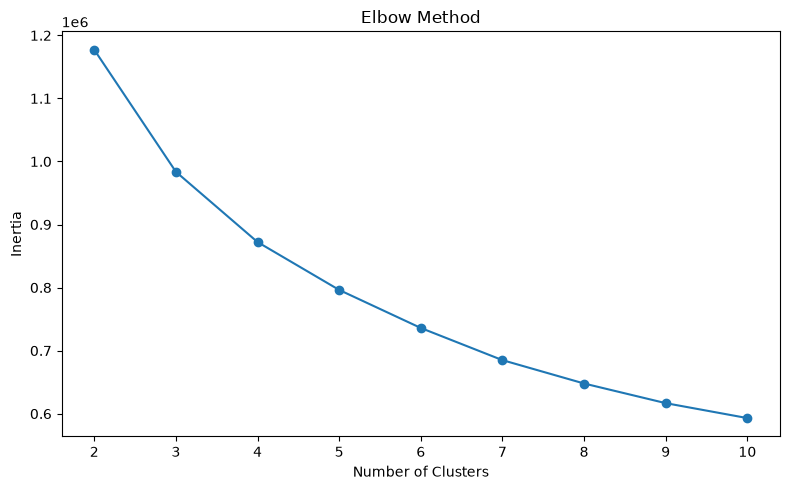

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "elbow_method.png",
    dpi=300,
)

plt.show()
plt.close()

## 10. Train Final Model ##

In [10]:
N_CLUSTERS = 5

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=10,
)

labels = kmeans.fit_predict(X_scaled)

## 11. Silhouette Score ##

In [11]:
score = silhouette_score(
    X_scaled,
    labels,
)

print(f"Silhouette Score: {score:.4f}")

Silhouette Score: 0.1761


## 12. Add Cluster Labels ##

In [12]:
cluster_df["cluster"] = labels

## 13. PCA Projection ##

In [13]:
pca = PCA(n_components=2, random_state=42)

projection = pca.fit_transform(X_scaled)

cluster_df["pca_1"] = projection[:, 0]
cluster_df["pca_2"] = projection[:, 1]

## 14. Cluster Plot ##

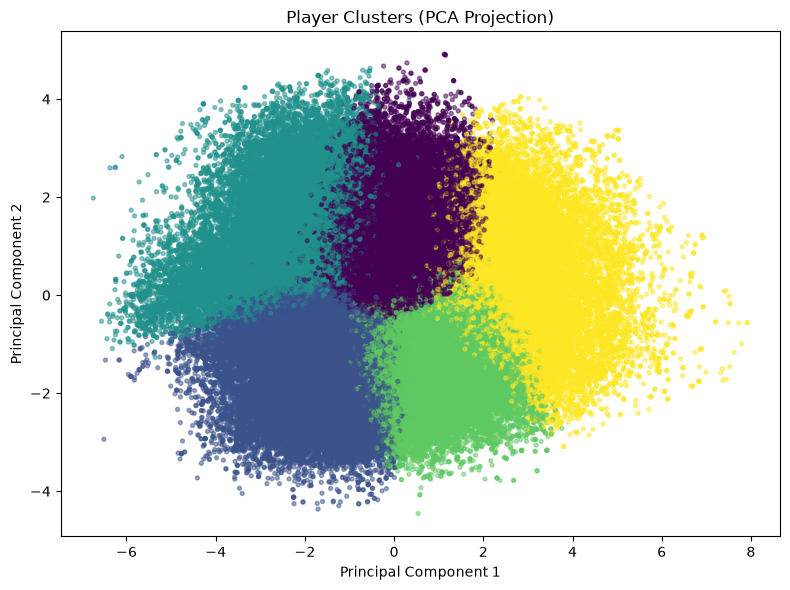

In [14]:
plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    cluster_df["pca_1"],
    cluster_df["pca_2"],
    c=cluster_df["cluster"],
    s=8,
    alpha=0.5,
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Player Clusters (PCA Projection)")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR / "player_clusters.png",
    dpi=300,
)

plt.show()
plt.close()

## 15. Cluster Summary ##

In [15]:
summary = (
    cluster_df
    .groupby("cluster")
    .agg(
        {
            "overall": "mean",
            "age": "mean",
            "potential": "mean",
            "pace": "mean",
            "shooting": "mean",
            "passing": "mean",
            "dribbling": "mean",
            "defending": "mean",
            "physic": "mean",
        }
    )
)

summary

,overall,age,potential,pace,shooting,passing,dribbling,defending,physic
cluster,,,,,,,,,
0,67.199830,27.452953,69.374634,64.919727,50.157261,59.527426,61.865956,62.312028,70.509197
1,57.484230,20.376073,67.916800,67.822524,47.891986,50.091328,57.964883,39.560361,54.359960
2,62.707838,24.210127,68.464735,57.564662,31.675709,43.069991,45.279734,62.259802,68.495979
3,67.232962,24.580408,71.752750,75.631887,62.891341,59.634750,68.554543,34.698684,60.668676
4,75.427634,25.986043,78.514166,73.755967,65.281821,70.151291,73.962247,59.097244,70.640509


## 16. Save Results ##

In [16]:
cluster_df.to_parquet(
    PROCESSED_DATA_DIR / "player_clusters.parquet",
    index=False,
)

summary.to_csv(
    TABLES_DIR / "cluster_summary.csv",
)

## 17. Save Models ##

In [17]:
joblib.dump(
    scaler,
    MODELS_DIR / "cluster_scaler.pkl",
)

joblib.dump(
    kmeans,
    MODELS_DIR / "kmeans_model.pkl",
)

joblib.dump(
    pca,
    MODELS_DIR / "pca_model.pkl",
)

['/Users/subhankarbiswas/fifa-player-analytics/models/pca_model.pkl']

## Conclusions

- Review cluster characteristics.
- Compare average player attributes across clusters.
- Use these segments for scouting and player profiling.

### Next

Proceed to **Notebook 08 — Model Explainability**.